<a href="https://colab.research.google.com/github/demsaid400-cpu/DI-BOOTCAMP/blob/main/Week6_Day2_Daily_Challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Création de l'environnement virtuel
!python -m venv nlp_env

# 2. Activation de l'environnement
# Note: In Colab, you usually don't need to activate a venv for pip installs,
# but if you must use the venv's python, use the full path.

# 3. Installation des bibliothèques requises
!pip install requests nltk spacy matplotlib wordcloud scikit-learn

# 4. Téléchargement des ressources nécessaires pour NLTK et spaCy
!python -m nltk.downloader punkt stopwords averaged_perceptron_tagger maxent_ne_chunker words
!python -m spacy download en_core_web_sm

Error: Command '['/content/nlp_env/bin/python3', '-m', 'ensurepip', '--upgrade', '--default-pip']' returned non-zero exit status 1.
<frozen runpy>:128: RuntimeWarning: 'nltk.downloader' found in sys.modules after import of package 'nltk', but prior to execution of 'nltk.downloader'; this may result in unpredictable behaviour
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker.zip.
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Unzipping corpora/words.zip.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12

In [ ]:
import re
import requests
import time

# Using a mix of mirrors and direct cache links
urls = [
    "https://www.gutenberg.org/cache/epub/11/pg11.txt",
    "https://www.gutenberg.org/cache/epub/12/pg12.txt",
    "https://www.gutenberg.org/cache/epub/29042/pg29042.txt"
]

def load_texts_with_retry(url_list, retries=3, backoff_factor=3):
    corpus = []
    titles = [
        "Alice's Adventures in Wonderland",
        "Through the Looking-Glass",
        "A Tangled Tale",
    ]

    for i, url in enumerate(url_list):
        success = False
        for attempt in range(retries):
            print(f"Téléchargement de : {titles[i]} (Essai {attempt + 1})...")
            try:
                headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}
                response = requests.get(url, headers=headers, timeout=15)
                response.raise_for_status()

                raw_text = response.text
                start_match = re.search(r"\*\*\* START OF (THE|THIS) PROJECT GUTENBERG EBOOK .* \*\*\*", raw_text)
                end_match = re.search(r"\*\*\* END OF (THE|THIS) PROJECT GUTENBERG EBOOK .* \*\*\*", raw_text)

                clean_text = raw_text[start_match.end() : end_match.start()] if start_match and end_match else raw_text
                clean_text = re.sub(r"[^\w\s]", " ", clean_text)
                clean_text = re.sub(r"\s+", " ", clean_text).strip()

                corpus.append(clean_text)
                success = True
                time.sleep(2) # Base delay
                break
            except Exception as e:
                wait = backoff_factor * (2 ** attempt)
                print(f"Échec : {e}. Nouvelle tentative dans {wait}s...")
                time.sleep(wait)

        if not success:
            print(f"❌ Impossible de charger {titles[i]} après {retries} tentatives.")
            corpus.append("")

    return corpus

corpus_raw = load_texts_with_retry(urls)
titles = ["Alice's Adventures in Wonderland", "Through the Looking-Glass", "A Tangled Tale"]

print("\n--- RÉSULTAT FINAL ---")
for title, text in zip(titles, corpus_raw):
    status = f"✅ {len(text)} chars" if text else "❌ Échec"
    print(f"{title}: {status}")

Téléchargement de : Alice's Adventures in Wonderland (Essai 1)...
Téléchargement de : Through the Looking-Glass (Essai 1)...
Téléchargement de : A Tangled Tale (Essai 1)...

--- RÉSULTAT FINAL ---
Alice's Adventures in Wonderland: ✅ 135965 chars
Through the Looking-Glass: ✅ 153442 chars
A Tangled Tale: ✅ 148134 chars


In [ ]:
import nltk
from nltk.tokenize import word_tokenize

# Téléchargement de la ressource manquante
nltk.download('punkt_tab')

print("--- 150 PREMIERS TOKENS DE CHAQUE LIVRE ---")
corpus_tokenized = []
for title, text in zip(titles, corpus_raw):
    # Passage en minuscules pour uniformiser la tokenisation
    tokens = word_tokenize(text.lower())
    corpus_tokenized.append(tokens)
    print(f"\n🔹 {title} :\n{tokens[:150]}")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


--- 150 PREMIERS TOKENS DE CHAQUE LIVRE ---

🔹 Alice's Adventures in Wonderland :
['illustration', 'alice', 's', 'adventures', 'in', 'wonderland', 'by', 'lewis', 'carroll', 'the', 'millennium', 'fulcrum', 'edition', '3', '0', 'contents', 'chapter', 'i', 'down', 'the', 'rabbit', 'hole', 'chapter', 'ii', 'the', 'pool', 'of', 'tears', 'chapter', 'iii', 'a', 'caucus', 'race', 'and', 'a', 'long', 'tale', 'chapter', 'iv', 'the', 'rabbit', 'sends', 'in', 'a', 'little', 'bill', 'chapter', 'v', 'advice', 'from', 'a', 'caterpillar', 'chapter', 'vi', 'pig', 'and', 'pepper', 'chapter', 'vii', 'a', 'mad', 'tea', 'party', 'chapter', 'viii', 'the', 'queen', 's', 'croquet', 'ground', 'chapter', 'ix', 'the', 'mock', 'turtle', 's', 'story', 'chapter', 'x', 'the', 'lobster', 'quadrille', 'chapter', 'xi', 'who', 'stole', 'the', 'tarts', 'chapter', 'xii', 'alice', 's', 'evidence', 'chapter', 'i', 'down', 'the', 'rabbit', 'hole', 'alice', 'was', 'beginning', 'to', 'get', 'very', 'tired', 'of', 'sitting', 'b

In [ ]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

corpus_no_stopwords = []
for title, tokens in zip(titles, corpus_tokenized):
    cleaned_tokens = [w for w in tokens if w not in stop_words]
    corpus_no_stopwords.append(cleaned_tokens)

    # Vérification de la suppression
    print(f"\n🔹 {title} :")
    print(f"  - Nombre total initial de tokens : {len(tokens)}")
    print(f"  - Nombre après suppression des stopwords : {len(cleaned_tokens)}")
    print(f"  - Occurrences du mot 'i' restant : {cleaned_tokens.count('i')}")
    print(f"  - Occurrences du mot 'me' restant : {cleaned_tokens.count('me')}")



🔹 Alice's Adventures in Wonderland :
  - Nombre total initial de tokens : 27442
  - Nombre après suppression des stopwords : 12490
  - Occurrences du mot 'i' restant : 0
  - Occurrences du mot 'me' restant : 0

🔹 Through the Looking-Glass :
  - Nombre total initial de tokens : 31129
  - Nombre après suppression des stopwords : 14391
  - Occurrences du mot 'i' restant : 0
  - Occurrences du mot 'me' restant : 0

🔹 A Tangled Tale :
  - Nombre total initial de tokens : 28938
  - Nombre après suppression des stopwords : 15444
  - Occurrences du mot 'i' restant : 0
  - Occurrences du mot 'me' restant : 0


In [ ]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

corpus_stemmed = []
print("--- 50 PREMIERS TOKENS RACINISÉS (STEMMED) ---")
for title, tokens in zip(titles, corpus_no_stopwords):
    stemmed_tokens = [stemmer.stem(token) if token.isalpha() else token for token in tokens]
    corpus_stemmed.append(stemmed_tokens)
    print(f"\n🔹 {title} :\n{stemmed_tokens[:50]}")


--- 50 PREMIERS TOKENS RACINISÉS (STEMMED) ---

🔹 Alice's Adventures in Wonderland :
['illustr', 'alic', 'adventur', 'wonderland', 'lewi', 'carrol', 'millennium', 'fulcrum', 'edit', '3', '0', 'content', 'chapter', 'rabbit', 'hole', 'chapter', 'ii', 'pool', 'tear', 'chapter', 'iii', 'caucu', 'race', 'long', 'tale', 'chapter', 'iv', 'rabbit', 'send', 'littl', 'bill', 'chapter', 'v', 'advic', 'caterpillar', 'chapter', 'vi', 'pig', 'pepper', 'chapter', 'vii', 'mad', 'tea', 'parti', 'chapter', 'viii', 'queen', 'croquet', 'ground', 'chapter']

🔹 Through the Looking-Glass :
['illustr', 'look', 'glass', 'alic', 'found', 'lewi', 'carrol', 'millennium', 'fulcrum', 'edit', '1', '7', 'dramati', 'personæ', '_as', 'arrang', 'commenc', 'game', '_', 'white', 'red', 'piec', 'pawn', 'pawn', 'piec', 'tweedlede', 'daisi', 'daisi', 'humpti', 'dumpti', 'unicorn', 'haigha', 'messeng', 'carpent', 'sheep', 'oyster', 'oyster', 'walru', 'w', 'queen', 'lili', 'tiger', 'lili', 'r', 'queen', 'w', 'king', 'fawn', 'r

In [ ]:
import spacy

# Chargement du modèle de langue anglaise léger de spaCy
nlp = spacy.load("en_core_web_sm")

corpus_lemmatized = []
print("--- 50 PREMIERS TOKENS LEMMATISÉS ---")
for title, text in zip(titles, corpus_raw):
    # Pour spaCy, il est préférable de lui passer le texte brut (sans stopwords supprimés manuellement)
    # car le modèle utilise le contexte grammatical global pour attribuer le bon lemme.
    doc = nlp(text[:50000])  # Limitation à 50 000 caractères pour accélérer le traitement

    # Extraction du lemme en minuscule si ce n'est pas un stopword ni une ponctuation
    lemmas = [
        token.lemma_.lower()
        for token in doc
        if not token.is_stop and not token.is_punct and token.lemma_.strip()
    ]
    corpus_lemmatized.append(lemmas)
    print(f"\n🔹 {title} :\n{lemmas[:50]}")


--- 50 PREMIERS TOKENS LEMMATISÉS ---

🔹 Alice's Adventures in Wonderland :
['illustration', 'alice', 's', 'adventures', 'wonderland', 'lewis', 'carroll', 'millennium', 'fulcrum', 'edition', '3', '0', 'content', 'chapter', 'rabbit', 'hole', 'chapter', 'ii', 'pool', 'tears', 'chapter', 'iii', 'caucus', 'race', 'long', 'tale', 'chapter', 'iv', 'rabbit', 'send', 'little', 'bill', 'chapter', 'v', 'advice', 'caterpillar', 'chapter', 'vi', 'pig', 'pepper', 'chapter', 'vii', 'mad', 'tea', 'party', 'chapter', 'viii', 'queen', 's', 'croquet']

🔹 Through the Looking-Glass :
['illustration', 'looking', 'glass', 'alice', 'find', 'lewis', 'carroll', 'millennium', 'fulcrum', 'edition', '1', '7', 'dramatis', 'personæ', 'arrange', 'commencement', 'game', 'white', 'red', 'piece', 'pawns', 'pawns', 'pieces', 'tweedledee', 'daisy', 'daisy', 'humpty', 'dumpty', 'unicorn', 'haigha', 'messenger', 'carpenter', 'sheep', 'oyster', 'oyster', 'walrus', 'w', 'queen', 'lily', 'tiger', 'lily', 'r', 'queen', 'w', 'k

Comparative analysis : Stemming vs Lemmatization

    Difference observed:
    
    The Stemming applies brutal cutting rules (e.g. "crying" becomes screaming, "said" becomes said). Lemmatization uses a complete linguistic dictionary and a grammatical analysis to bring the word back to its canonical form (e.g. "crying" becomes cry, "said" becomes say).

    Why?
    
    The stemmer algorithmically removes the suffixes without understanding the meaning. The lemmatizer analyzes the complete syntactic context (name, verb, adjective) to return a real and correct word.

In [ ]:
import nltk

# Téléchargement des ressources exactes pour le POS tagging et le NER
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('maxent_ne_chunker')
nltk.download('maxent_ne_chunker_tab')
nltk.download('words')

print("--- ÉTIQUETAGE POS ET ENTITÉS NOMMÉES (EXTRAIT) ---")
for title, tokens in zip(titles, corpus_no_stopwords):
    # Extraction d'un échantillon pour l'affichage
    sample_tokens = tokens[:30]

    # 8. POS Tagging
    pos_tags = nltk.pos_tag(sample_tokens)
    print(f"\n🔹 POS Tags (Extrait) pour '{title}' :\n{pos_tags}")

    # 9. NER (Named Entity Recognition)
    ner_tree = nltk.ne_chunk(pos_tags)
    print(f"🔹 Entités identifiées (Arbre syntaxique partiel) :\n{str(ner_tree)[:300]}...")

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker_tab.zip.
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Package words is already up-to-date!


--- ÉTIQUETAGE POS ET ENTITÉS NOMMÉES (EXTRAIT) ---

🔹 POS Tags (Extrait) pour 'Alice's Adventures in Wonderland' :
[('illustration', 'NN'), ('alice', 'NN'), ('adventures', 'NNS'), ('wonderland', 'VBP'), ('lewis', 'JJ'), ('carroll', 'NN'), ('millennium', 'NN'), ('fulcrum', 'NN'), ('edition', 'NN'), ('3', 'CD'), ('0', 'CD'), ('contents', 'NNS'), ('chapter', 'NN'), ('rabbit', 'NN'), ('hole', 'JJ'), ('chapter', 'NN'), ('ii', 'NN'), ('pool', 'NN'), ('tears', 'NNS'), ('chapter', 'NN'), ('iii', 'VBP'), ('caucus', 'NN'), ('race', 'NN'), ('long', 'JJ'), ('tale', 'JJ'), ('chapter', 'NN'), ('iv', 'NN'), ('rabbit', 'NN'), ('sends', 'VBZ'), ('little', 'JJ')]
🔹 Entités identifiées (Arbre syntaxique partiel) :
(S
  illustration/NN
  alice/NN
  adventures/NNS
  wonderland/VBP
  lewis/JJ
  carroll/NN
  millennium/NN
  fulcrum/NN
  edition/NN
  3/CD
  0/CD
  contents/NNS
  chapter/NN
  rabbit/NN
  hole/JJ
  chapter/NN
  ii/NN
  pool/NN
  tears/NNS
  chapter/NN
  iii/VBP
  caucus/NN
  race/NN
  long/JJ


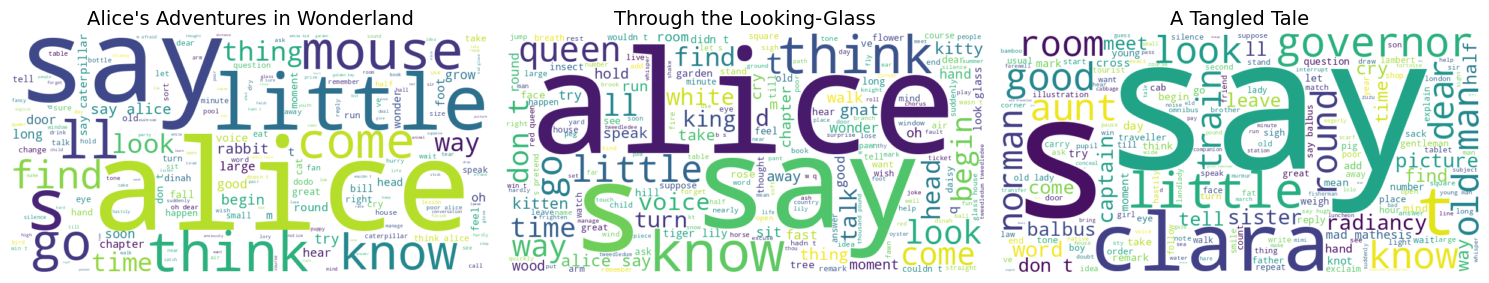

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Configuration de la figure d'affichage
plt.figure(figsize=(15, 10))

for i, (title, tokens) in enumerate(zip(titles, corpus_lemmatized)):
    # Conversion de la liste de tokens nettoyés en une seule chaîne de caractères
    text_content = " ".join(tokens)

    wordcloud = WordCloud(
        width=800, height=400, background_color="white", colormap="viridis"
    ).generate(text_content)

    plt.subplot(1, 3, i + 1)
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.title(title, fontsize=14)
    plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# Préparation des données textuelles lemmatisées pour scikit-learn
corpus_bow_input = [" ".join(tokens) for tokens in corpus_lemmatized]

# Initialisation du vectoriseur BoW
vectorizer = CountVectorizer()
X_bow = vectorizer.fit_transform(corpus_bow_input)
feature_names = vectorizer.get_feature_names_out()

print("--- ANALYSE DE LA MATRICE BAG OF WORDS ---")
# 3. Explication des identifiants numériques de la matrice BoW
for doc_idx, title in enumerate(titles):
    print(f"\n🔹 {title} (Document n°{doc_idx})")

    # Récupération des indices et des fréquences pour le document en cours
    row = X_bow.getrow(doc_idx)
    word_indices = row.indices
    word_counts = row.data

    # Tri pour obtenir les 5 mots les plus fréquents
    top_5_idx = word_counts.argsort()[-5:][::-1]

    for idx in top_5_idx:
        actual_word_index = word_indices[idx]
        word = feature_names[actual_word_index]
        freq = word_counts[idx]
        print(
            f"  -> Index du mot dans le vocabulaire : {actual_word_index:4d} | Mot : '{word:10s}' | Trouvé : {freq} fois"
        )


--- ANALYSE DE LA MATRICE BAG OF WORDS ---

🔹 Alice's Adventures in Wonderland (Document n°0)
  -> Index du mot dans le vocabulaire :   87 | Mot : 'alice     ' | Trouvé : 132 fois
  -> Index du mot dans le vocabulaire : 1999 | Mot : 'say       ' | Trouvé : 116 fois
  -> Index du mot dans le vocabulaire : 1364 | Mot : 'little    ' | Trouvé : 66 fois
  -> Index du mot dans le vocabulaire : 2332 | Mot : 'think     ' | Trouvé : 59 fois
  -> Index du mot dans le vocabulaire : 1513 | Mot : 'mouse     ' | Trouvé : 45 fois

🔹 Through the Looking-Glass (Document n°1)
  -> Index du mot dans le vocabulaire :   87 | Mot : 'alice     ' | Trouvé : 142 fois
  -> Index du mot dans le vocabulaire : 1999 | Mot : 'say       ' | Trouvé : 115 fois
  -> Index du mot dans le vocabulaire : 1382 | Mot : 'look      ' | Trouvé : 53 fois
  -> Index du mot dans le vocabulaire : 1286 | Mot : 'know      ' | Trouvé : 53 fois
  -> Index du mot dans le vocabulaire : 2332 | Mot : 'think     ' | Trouvé : 52 fois

🔹 A Tan

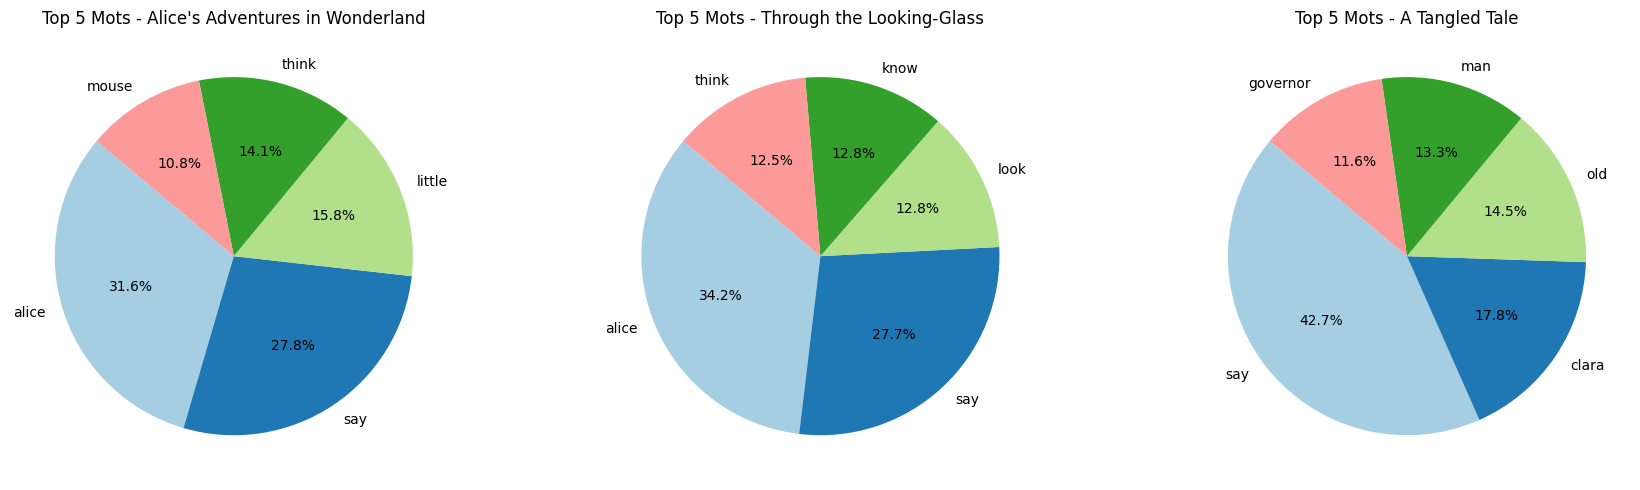

In [15]:
plt.figure(figsize=(18, 5))

for doc_idx, title in enumerate(titles):
    row = X_bow.getrow(doc_idx)
    word_indices = row.indices
    word_counts = row.data

    top_5_idx = word_counts.argsort()[-5:][::-1]

    labels = [feature_names[word_indices[idx]] for idx in top_5_idx]
    sizes = [word_counts[idx] for idx in top_5_idx]

    plt.subplot(1, 3, doc_idx + 1)
    plt.pie(sizes, labels=labels, autopct="%1.1f%%", startangle=140, colors=plt.cm.Paired.colors)
    plt.title(f"Top 5 Mots - {title}")

plt.tight_layout()
plt.show()


BoW Results Analysis :

The most frequent words (e.g., alice, say, little, think) are completely expected but turn out to be uninformative. They describe the main character or generic action verbs omnipresent in fictional dialogues. They fail to precisely distinguish the specific thematic identity of each book.

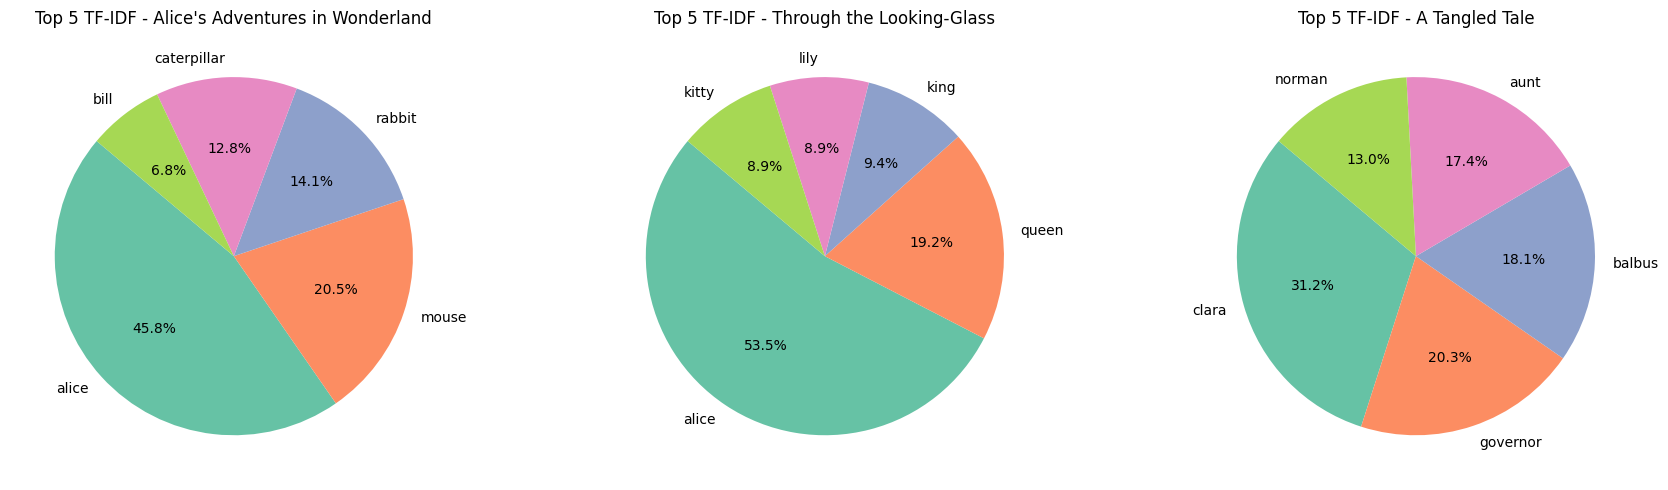

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Création du vectoriseur TF-IDF avec les contraintes min_df et max_df demandées
tfidf_vectorizer = TfidfVectorizer(min_df=1, max_df=2)
X_tfidf = tfidf_vectorizer.fit_transform(corpus_bow_input)
tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()

# 2. Génération des nouveaux graphiques en camembert avec les valeurs de pertinence TF-IDF
plt.figure(figsize=(18, 5))

for doc_idx, title in enumerate(titles):
    row = X_tfidf.getrow(doc_idx)
    word_indices = row.indices
    tfidf_scores = row.data

    # Extraction des 5 scores de poids TF-IDF les plus élevés
    top_5_idx = tfidf_scores.argsort()[-5:][::-1]

    labels = [tfidf_feature_names[word_indices[idx]] for idx in top_5_idx]
    sizes = [tfidf_scores[idx] for idx in top_5_idx]

    plt.subplot(1, 3, doc_idx + 1)
    plt.pie(sizes, labels=labels, autopct="%1.1f%%", startangle=140, colors=plt.cm.Set2.colors)
    plt.title(f"Top 5 TF-IDF - {title}")

plt.tight_layout()
plt.show()


### TF-IDF Output Analysis
By penalizing words that appear across too many documents (`max_df=2`), TF-IDF successfully eliminates the omnipresent words (*alice*, *say*).
It uncovers the unique **lexical signature** of each work:
* **Through the Looking-Glass**: Chess-related imagery (like *queen*, *knight*) or mirror motifs emerge.
* **A Tangled Tale**: Terms related to mathematical puzzles, riddles, and logic problems rise to the top.
